# Diagnostics CSV Overview

Quick visual overview for `evaluation_mismatch_diagnostics.csv`: distributions, issue tables, dataset/model splits, and review samples.

In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "src").exists() and (path / "results").exists():
            return path
    raise FileNotFoundError("Could not find repo root containing src/ and results/.")

ROOT = find_repo_root()
DIAG_PATH = ROOT / "results" / "nl2p_1" / "gpt-5.4" / "evaluation_mismatch_diagnostics.csv"
DIAG_PATH

WindowsPath('c:/anu/llm-action-extraction/results/experiment/nl2p_1/gpt-4o/evaluation_mismatch_diagnostics.csv')

In [2]:
df = pd.read_csv(DIAG_PATH)

text_cols = [
    "candidate_dataset_issue",
    "candidate_llm_issue",
    "reason",
    "gold_verb",
    "pred_verb",
    "gold_arguments",
    "pred_arguments",
]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("")

def parse_args(value):
    if not isinstance(value, str) or not value.strip():
        return []
    try:
        parsed = json.loads(value)
    except json.JSONDecodeError:
        return []
    return parsed if isinstance(parsed, list) else []

df["gold_arg_list"] = df["gold_arguments"].map(parse_args)
df["pred_arg_list"] = df["pred_arguments"].map(parse_args)
df["gold_arg_count"] = df["gold_arg_list"].map(len)
df["pred_arg_count"] = df["pred_arg_list"].map(len)
df["has_dataset_issue"] = df["candidate_dataset_issue"].ne("")
df["has_llm_issue"] = df["candidate_llm_issue"].ne("")

print(f"rows: {len(df):,}")
print(f"datasets: {sorted(df['dataset'].dropna().unique())}")
print(f"mismatch types: {sorted(df['mismatch_type'].dropna().unique())}")
df.head(3)

rows: 7,196
datasets: ['cooking', 'wikihow', 'win2k']
mismatch types: ['argument_mismatch', 'unmatched_gold_action', 'unmatched_prediction', 'wrong_action']


,dataset,solver,model,doc_id,docId,source_file,mismatch_type,candidate_dataset_issue,candidate_llm_issue,strong_dataset_issue,...,pred_verb,pred_arguments,gold_action,pred_action,gold_arg_list,pred_arg_list,gold_arg_count,pred_arg_count,has_dataset_issue,has_llm_issue
0,cooking,nl2p_1,gpt-4o,0,cooking:0,NaN,argument_mismatch,extra_arguments|extra_arguments:preposition_object,,extra_arguments|extra_arguments:preposition_object,...,mixing,"[""cream of mushroom condensed soup"", ""sour cream"", ""salt"", ""pepper"", ""onion"", ""cheese""]","{""verb"": ""mixing"", ""arguments"": [""cream"", ""soup"", ""cream"", ""salt"", ""pepper"", ""onion"", ""cheese""], ""act_idx"": 12, ""obj_idxs"": [[15, 19, 21, 22, 23, 24, 26], []], ""act_type"": 1, ""...","{""verb"": ""mixing"", ""arguments"": [""cream of mushroom condensed soup"", ""sour cream"", ""salt"", ""pepper"", ""onion"", ""cheese""]}","[cream, soup, cream, salt, pepper, onion, cheese]","[cream of mushroom condensed soup, sour cream, salt, pepper, onion, cheese]",7,6,True,False
1,cooking,nl2p_1,gpt-4o,0,cooking:0,NaN,unmatched_gold_action,,missing_actions,NaN,...,,[],"{""verb"": ""combined"", ""arguments"": [""cream"", ""soup"", ""cream"", ""salt"", ""pepper"", ""onion"", ""cheese""], ""act_idx"": 35, ""obj_idxs"": [[15, 19, 21, 22, 23, 24, 26], []], ""act_type"": 1,...",{},"[cream, soup, cream, salt, pepper, onion, cheese]",[],7,0,False,True
2,cooking,nl2p_1,gpt-4o,0,cooking:0,NaN,argument_mismatch,extra_arguments|extra_arguments:preposition_object,,extra_arguments|extra_arguments:preposition_object,...,mix,"[""hash browns""]","{""verb"": ""mix"", ""arguments"": [""cream"", ""soup"", ""cream"", ""salt"", ""pepper"", ""onion"", ""cheese"", ""browns""], ""act_idx"": 42, ""obj_idxs"": [[15, 19, 21, 22, 23, 24, 26, 40], []], ""act_...","{""verb"": ""mix"", ""arguments"": [""hash browns""]}","[cream, soup, cream, salt, pepper, onion, cheese, browns]",[hash browns],8,1,True,False


In [3]:
summary = (
    df.groupby(["dataset", "mismatch_type"], dropna=False)
    .agg(
        rows=("mismatch_type", "size"),
        dataset_issue_rows=("has_dataset_issue", "sum"),
        llm_issue_rows=("has_llm_issue", "sum"),
        avg_gold_args=("gold_arg_count", "mean"),
        avg_pred_args=("pred_arg_count", "mean"),
    )
    .reset_index()
)
summary

,dataset,mismatch_type,rows,dataset_issue_rows,llm_issue_rows,avg_gold_args,avg_pred_args
0,cooking,argument_mismatch,1018,598,420,1.666012,1.344794
1,cooking,unmatched_gold_action,361,0,361,1.116343,0.000000
2,cooking,unmatched_prediction,226,225,1,0.000000,0.907080
3,cooking,wrong_action,305,0,305,1.337705,1.442623
4,wikihow,argument_mismatch,2119,1351,768,1.847570,1.173667
5,wikihow,unmatched_gold_action,922,0,922,1.522777,0.000000
6,wikihow,unmatched_prediction,742,735,7,0.000000,0.994609
7,wikihow,wrong_action,625,0,625,1.643200,1.353600
8,win2k,argument_mismatch,673,490,183,1.907875,0.961367
9,win2k,unmatched_gold_action,143,0,143,1.601399,0.000000


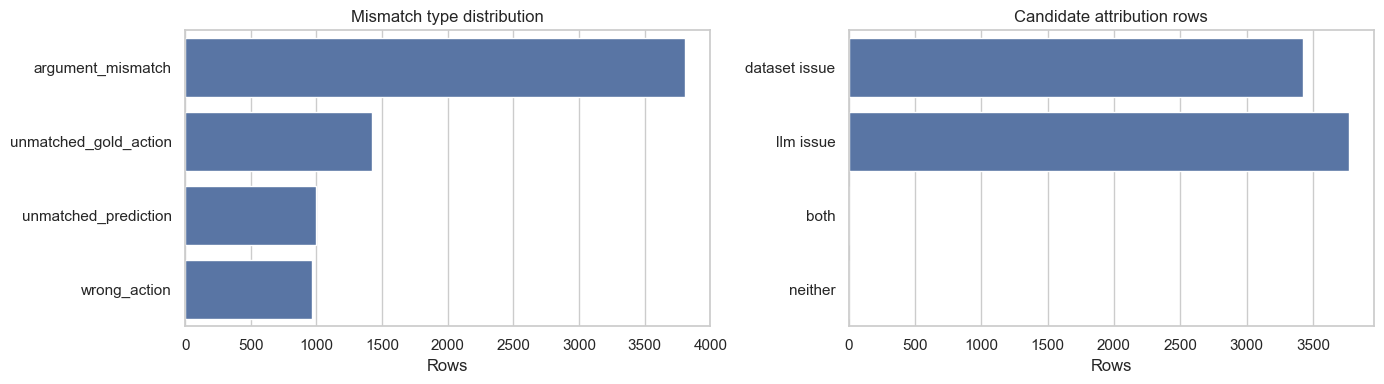

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, y="mismatch_type", order=df["mismatch_type"].value_counts().index, ax=axes[0])
axes[0].set_title("Mismatch type distribution")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("")

issue_source = pd.DataFrame({
    "source": ["dataset issue", "llm issue", "both", "neither"],
    "rows": [
        int((df["has_dataset_issue"] & ~df["has_llm_issue"]).sum()),
        int((~df["has_dataset_issue"] & df["has_llm_issue"]).sum()),
        int((df["has_dataset_issue"] & df["has_llm_issue"]).sum()),
        int((~df["has_dataset_issue"] & ~df["has_llm_issue"]).sum()),
    ],
})
sns.barplot(data=issue_source, x="rows", y="source", ax=axes[1])
axes[1].set_title("Candidate attribution rows")
axes[1].set_xlabel("Rows")
axes[1].set_ylabel("")

plt.tight_layout()

In [5]:
def split_issue_labels(frame, column):
    rows = []
    for idx, value in frame[column].items():
        for label in str(value).split("|"):
            label = label.strip()
            if label:
                rows.append({"row_id": idx, "label": label})
    return pd.DataFrame(rows)

dataset_labels = split_issue_labels(df, "candidate_dataset_issue")
llm_labels = split_issue_labels(df, "candidate_llm_issue")

display(dataset_labels["label"].value_counts().rename_axis("dataset_issue").reset_index(name="rows"))
display(llm_labels["label"].value_counts().rename_axis("llm_issue").reset_index(name="rows"))

,dataset_issue,rows
0,extra_arguments,2114
1,extra_arguments:unnecessary_head_or_modifier_split,1421
2,missing_actions,985
3,wrong_arguments,703
4,extra_arguments:preposition_object,693
5,missing_arguments,429
6,missing_arguments:preposition_object,429
7,wrong_arguments:gold_pronoun_or_generic_reference,39


,llm_issue,rows
0,missing_actions,1426
1,missing_arguments,1122
2,extra_arguments,969
3,wrong_actions,967
4,wrong_arguments,720
5,extra_arguments:preposition_argument,44
6,extra_actions,8


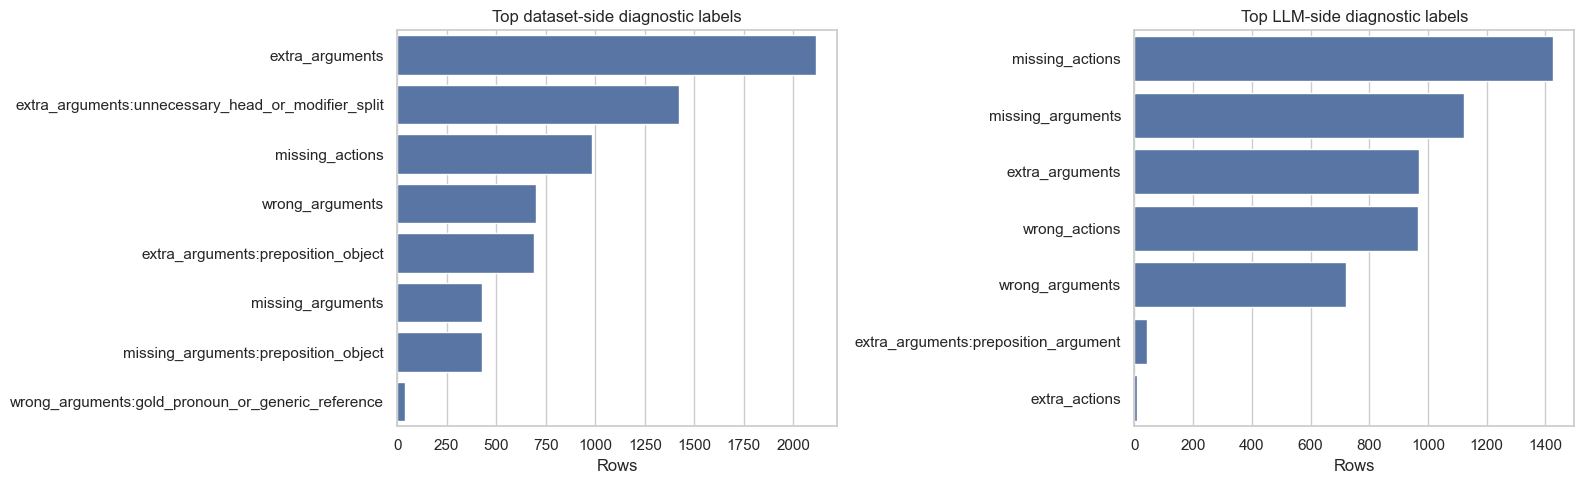

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_dataset = dataset_labels["label"].value_counts().head(12)
sns.barplot(x=top_dataset.values, y=top_dataset.index, ax=axes[0])
axes[0].set_title("Top dataset-side diagnostic labels")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("")

top_llm = llm_labels["label"].value_counts().head(12)
sns.barplot(x=top_llm.values, y=top_llm.index, ax=axes[1])
axes[1].set_title("Top LLM-side diagnostic labels")
axes[1].set_xlabel("Rows")
axes[1].set_ylabel("")

plt.tight_layout()

## Focus: Gold Split and Preposition Object Coverage

This section measures the share of the two main argument-side GT issue families by domain. It reports percentages against three denominators: all diagnostic mismatch rows, argument-mismatch rows only, and dataset-side argument-issue rows.

In [7]:
FOCUS_ISSUES = {
    "gold_split": "unnecessary_head_or_modifier_split",
    "preposition_object": "preposition_object",
    "gold_pronoun_or_generic_reference": "gold_pronoun_or_generic_reference",
    "gold_missing_valid_argument": "gold_missing_valid_argument",
}

def has_issue(frame, issue_substring):
    return frame["candidate_dataset_issue"].str.contains(issue_substring, regex=False, na=False)

def domain_coverage_table(frame):
    rows = []
    for domain, group in frame.groupby("dataset", dropna=False):
        all_rows = len(group)
        arg_rows = int(group["mismatch_type"].eq("argument_mismatch").sum())
        dataset_arg_mask = group["mismatch_type"].eq("argument_mismatch") & group["has_dataset_issue"]
        dataset_arg_rows = int(dataset_arg_mask.sum())

        for issue_name, issue_substring in FOCUS_ISSUES.items():
            mask = has_issue(group, issue_substring)
            count = int(mask.sum())
            arg_count = int((mask & group["mismatch_type"].eq("argument_mismatch")).sum())
            rows.append({
                "dataset": domain,
                "issue": issue_name,
                "rows": count,
                "arg_mismatch_rows": arg_count,
                "all_diagnostic_rows": all_rows,
                "all_argument_mismatch_rows": arg_rows,
                "dataset_side_argument_issue_rows": dataset_arg_rows,
                "pct_of_all_diagnostics": count / all_rows if all_rows else 0,
                "pct_of_argument_mismatches": arg_count / arg_rows if arg_rows else 0,
                "pct_of_dataset_side_argument_issues": arg_count / dataset_arg_rows if dataset_arg_rows else 0,
            })
    return pd.DataFrame(rows)

coverage = domain_coverage_table(df)
coverage_display = coverage.copy()
for col in ["pct_of_all_diagnostics", "pct_of_argument_mismatches", "pct_of_dataset_side_argument_issues"]:
    coverage_display[col] = (coverage_display[col] * 100).round(1)
coverage_display.sort_values(["dataset", "rows"], ascending=[True, False])

,dataset,issue,rows,arg_mismatch_rows,all_diagnostic_rows,all_argument_mismatch_rows,dataset_side_argument_issue_rows,pct_of_all_diagnostics,pct_of_argument_mismatches,pct_of_dataset_side_argument_issues
1,cooking,preposition_object,392,392,1910,1018,598,20.5,38.5,65.6
0,cooking,gold_split,241,241,1910,1018,598,12.6,23.7,40.3
2,cooking,gold_pronoun_or_generic_reference,10,10,1910,1018,598,0.5,1.0,1.7
3,cooking,gold_missing_valid_argument,0,0,1910,1018,598,0.0,0.0,0.0
4,wikihow,gold_split,757,757,4408,2119,1351,17.2,35.7,56.0
5,wikihow,preposition_object,618,618,4408,2119,1351,14.0,29.2,45.7
6,wikihow,gold_pronoun_or_generic_reference,28,28,4408,2119,1351,0.6,1.3,2.1
7,wikihow,gold_missing_valid_argument,0,0,4408,2119,1351,0.0,0.0,0.0
8,win2k,gold_split,423,423,878,673,490,48.2,62.9,86.3
9,win2k,preposition_object,68,68,878,673,490,7.7,10.1,13.9


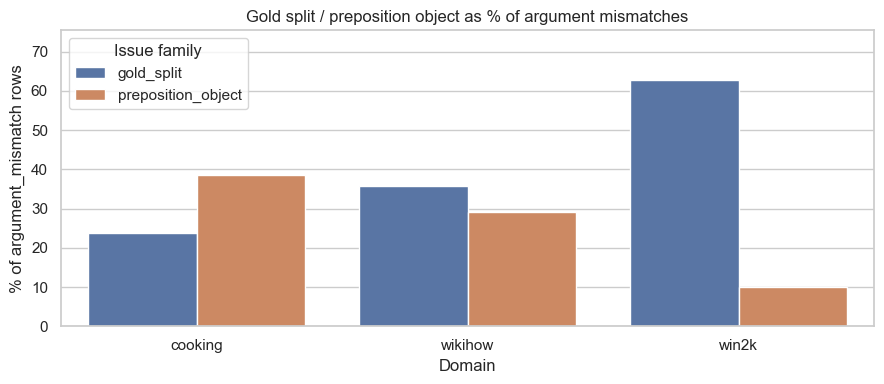

In [8]:
plot_issues = ["gold_split", "preposition_object"]
plot_data = coverage[coverage["issue"].isin(plot_issues)].copy()
plot_data["percent"] = plot_data["pct_of_argument_mismatches"] * 100

plt.figure(figsize=(9, 4))
sns.barplot(data=plot_data, x="dataset", y="percent", hue="issue")
plt.title("Gold split / preposition object as % of argument mismatches")
plt.xlabel("Domain")
plt.ylabel("% of argument_mismatch rows")
plt.ylim(0, max(5, plot_data["percent"].max() * 1.2))
plt.legend(title="Issue family")
plt.tight_layout()

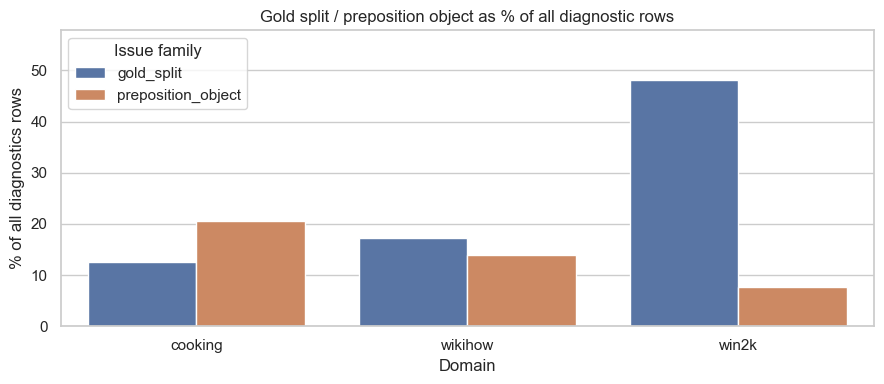

In [9]:
plot_data = coverage[coverage["issue"].isin(plot_issues)].copy()
plot_data["percent"] = plot_data["pct_of_all_diagnostics"] * 100

plt.figure(figsize=(9, 4))
sns.barplot(data=plot_data, x="dataset", y="percent", hue="issue")
plt.title("Gold split / preposition object as % of all diagnostic rows")
plt.xlabel("Domain")
plt.ylabel("% of all diagnostics rows")
plt.ylim(0, max(5, plot_data["percent"].max() * 1.2))
plt.legend(title="Issue family")
plt.tight_layout()

In [10]:
combined = []
for domain, group in df.groupby("dataset", dropna=False):
    arg_group = group[group["mismatch_type"].eq("argument_mismatch")]
    denom = len(arg_group)
    split_mask = has_issue(arg_group, FOCUS_ISSUES["gold_split"])
    prep_mask = has_issue(arg_group, FOCUS_ISSUES["preposition_object"])
    union_mask = split_mask | prep_mask
    combined.append({
        "dataset": domain,
        "argument_mismatch_rows": denom,
        "gold_split_rows": int(split_mask.sum()),
        "preposition_object_rows": int(prep_mask.sum()),
        "split_or_preposition_rows": int(union_mask.sum()),
        "pct_split_or_preposition_of_argument_mismatches": (union_mask.sum() / denom * 100) if denom else 0,
    })
combined = pd.DataFrame(combined)
combined["pct_split_or_preposition_of_argument_mismatches"] = combined["pct_split_or_preposition_of_argument_mismatches"].round(1)
combined

,dataset,argument_mismatch_rows,gold_split_rows,preposition_object_rows,split_or_preposition_rows,pct_split_or_preposition_of_argument_mismatches
0,cooking,1018,241,392,589,57.9
1,wikihow,2119,757,618,1330,62.8
2,win2k,673,423,68,489,72.7


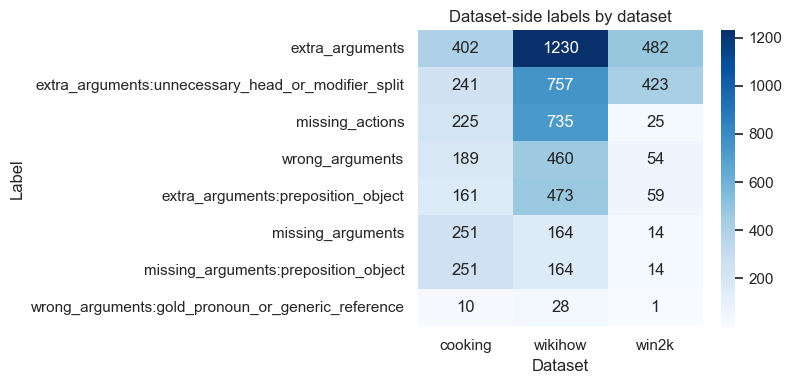

In [11]:
if not dataset_labels.empty:
    dataset_heatmap = (
        dataset_labels.join(df[["dataset"]], on="row_id")
        .pivot_table(index="label", columns="dataset", values="row_id", aggfunc="count", fill_value=0)
    )
    dataset_heatmap = dataset_heatmap.loc[dataset_heatmap.sum(axis=1).sort_values(ascending=False).head(15).index]
    plt.figure(figsize=(8, max(4, 0.35 * len(dataset_heatmap))))
    sns.heatmap(dataset_heatmap, annot=True, fmt="d", cmap="Blues")
    plt.title("Dataset-side labels by dataset")
    plt.xlabel("Dataset")
    plt.ylabel("Label")
    plt.tight_layout()
else:
    print("No dataset-side issue labels found.")

pred_arg_count,0,1,2,3,4,5,6,7,10,12,All
gold_arg_count,,,,,,,,,,,
0,0,70,6,2,0,1,0,0,0,0,79
1,398,626,463,46,8,2,0,0,0,0,1543
2,90,1216,174,40,2,1,0,0,0,0,1523
3,18,347,102,6,3,1,1,0,1,0,479
4,4,69,27,14,1,2,0,0,0,0,117
5,2,18,5,6,12,1,1,0,0,0,45
6,1,4,1,1,2,1,0,0,0,0,10
7,0,0,0,0,4,1,3,0,0,0,8
8,0,2,0,0,0,0,1,0,0,0,3


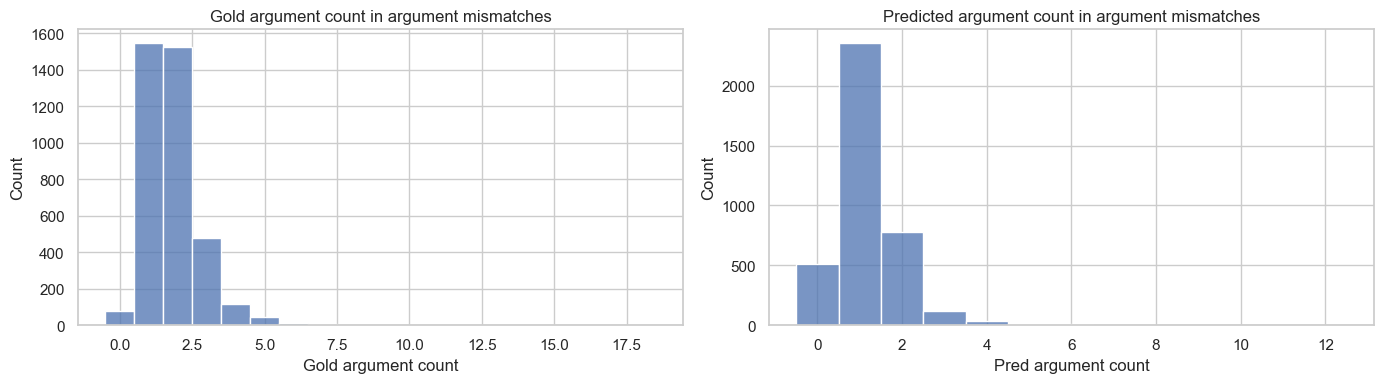

In [12]:
argument_rows = df[df["mismatch_type"].eq("argument_mismatch")].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=argument_rows, x="gold_arg_count", discrete=True, ax=axes[0])
axes[0].set_title("Gold argument count in argument mismatches")
axes[0].set_xlabel("Gold argument count")

sns.histplot(data=argument_rows, x="pred_arg_count", discrete=True, ax=axes[1])
axes[1].set_title("Predicted argument count in argument mismatches")
axes[1].set_xlabel("Pred argument count")

plt.tight_layout()

pd.crosstab(argument_rows["gold_arg_count"], argument_rows["pred_arg_count"], margins=True)

In [13]:
verb_table = (
    df.assign(pred_verb_norm=df["pred_verb"].str.lower().str.strip(), gold_verb_norm=df["gold_verb"].str.lower().str.strip())
    .groupby(["mismatch_type", "gold_verb_norm", "pred_verb_norm"], dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)
verb_table.head(40)

,mismatch_type,gold_verb_norm,pred_verb_norm,rows
85,argument_mismatch,click,click,437
664,argument_mismatch,use,use,161
0,argument_mismatch,add,add,155
1117,unmatched_gold_action,use,,142
365,argument_mismatch,place,place,141
161,argument_mismatch,double-click,double-click,85
448,argument_mismatch,remove,remove,84
1353,unmatched_prediction,,let,82
1119,unmatched_gold_action,using,,78
384,argument_mismatch,pour,pour,75


In [14]:
def sample_rows(issue=None, issue_col="candidate_dataset_issue", dataset=None, mismatch_type=None, n=10, random_state=7):
    subset = df.copy()
    if issue:
        subset = subset[subset[issue_col].str.contains(issue, regex=False, na=False)]
    if dataset:
        subset = subset[subset["dataset"].eq(dataset)]
    if mismatch_type:
        subset = subset[subset["mismatch_type"].eq(mismatch_type)]
    if len(subset) > n:
        subset = subset.sample(n=n, random_state=random_state)
    cols = [
        "dataset",
        "doc_id",
        "mismatch_type",
        "candidate_dataset_issue",
        "candidate_llm_issue",
        "reason",
        "gold_verb",
        "gold_arguments",
        "pred_verb",
        "pred_arguments",
        "original_text",
    ]
    return subset[cols]

# Examples:
# sample_rows(issue="gold_pronoun_or_generic_reference", n=10)
# sample_rows(issue="gold_missing_valid_argument", n=10)
# sample_rows(issue="preposition_object", n=10)
# sample_rows(issue="unnecessary_head_or_modifier_split", n=10)
sample_rows(n=5)

,dataset,doc_id,mismatch_type,candidate_dataset_issue,candidate_llm_issue,reason,gold_verb,gold_arguments,pred_verb,pred_arguments,original_text
5779,wikihow,129,unmatched_prediction,missing_actions,,unused prediction verb appears in original text; annotation may have missed this action,,[],stop,"[""the infection""]",Prune a select few trees in summer or fall. These trees can leak sap onto the ground below if pruned in the late fall or winter. Maples elms walnuts dogwoods and birches should...
4339,wikihow,84,unmatched_gold_action,,missing_actions,gold action was not matched by any prediction,place,"[""nozzle""]",,[],Shut off the sprinkler. Make sure the sprinkler is not hooked up to running water. This will make changing the sprinkler nozzle easier. You may want to change the sprinkler noz...
6902,win2k,107,argument_mismatch,extra_arguments|extra_arguments:unnecessary_head_or_modifier_split,,gold has arguments not matched by prediction; gold unmatched argument looks like a split modifier/head word,Click,"[""advanced"", ""settings"", ""tab""]",Click,"[""the advanced settings tab""]",Click start point to programs. Click administrative tools and then click computer management. Click system tools and then click device manager. Expand ide ata/atapi controllers...
610,cooking,31,argument_mismatch,,missing_arguments,gold has arguments not matched by prediction,Preheat,"[""oven""]",Preheat,[],How to make cheesecake. Preheat oven to 350F. Grease the springform pan well. Place the crushed grahams in a bowl. Cut in the melted butter and press the mixture onto the botto...
5907,wikihow,134,unmatched_gold_action,,missing_actions,gold action was not matched by any prediction,use,"[""drill""]",,[],Choose or clean out a child’s sand box. You can either purchase a new plastic sandbox (preferably one that is BPA free) or use an old one that your child no longer uses. If you...
